In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\abhir\Downloads\global_ads_performance_dataset.csv")
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,Click Through Rate,Cost Per Click,ad_spend,conversions,Cost Per Acquisition,revenue,Return On Ad Spend
0,21-01-2024,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80
1,22-01-2024,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41
2,15-06-2024,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06
3,02-01-2024,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45
4,22-02-2024,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  1800 non-null   object 
 1   platform              1800 non-null   object 
 2   campaign_type         1800 non-null   object 
 3   industry              1800 non-null   object 
 4   country               1800 non-null   object 
 5   impressions           1800 non-null   int64  
 6   clicks                1800 non-null   int64  
 7   Click Through Rate    1800 non-null   float64
 8   Cost Per Click        1800 non-null   float64
 9   ad_spend              1800 non-null   float64
 10  conversions           1800 non-null   int64  
 11  Cost Per Acquisition  1800 non-null   float64
 12  revenue               1800 non-null   float64
 13  Return On Ad Spend    1800 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 197.0+ KB


In [41]:
df['date'] = pd.to_datetime(df['date'],errors='coerce')

df['months'] = df['date'].dt.strftime('%b')

In [5]:
df.isnull().sum()

date                    0
platform                0
campaign_type           0
industry                0
country                 0
impressions             0
clicks                  0
Click Through Rate      0
Cost Per Click          0
ad_spend                0
conversions             0
Cost Per Acquisition    0
revenue                 0
Return On Ad Spend      0
date_year               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,date,impressions,clicks,Click Through Rate,Cost Per Click,ad_spend,conversions,Cost Per Acquisition,revenue,Return On Ad Spend,date_year
count,1800,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.0
mean,2024-06-28 12:56:00,102919.018889,3962.675556,0.038427,1.572756,6171.527272,181.562222,46.608961,30101.850450,6.450367,2024.0
min,2024-01-01 00:00:00,5059.000000,91.000000,0.008900,0.280000,58.000000,2.000000,4.800000,142.690000,0.130000,2024.0
25%,2024-03-27 18:00:00,54948.000000,1678.000000,0.025400,0.950000,1966.587500,59.000000,20.202500,7275.757500,2.170000,2024.0
50%,2024-06-26 00:00:00,103653.000000,3318.000000,0.035550,1.460000,4393.860000,130.000000,33.375000,18362.965000,4.295000,2024.0
75%,2024-09-26 00:00:00,150470.250000,5628.000000,0.049800,2.050000,8455.830000,252.250000,56.812500,38963.385000,8.212500,2024.0
max,2024-12-30 00:00:00,199650.000000,16660.000000,0.095600,3.950000,38453.320000,1151.000000,335.860000,295028.260000,49.000000,2024.0
std,NaN,55740.900690,2941.858037,0.017082,0.800872,5776.996958,171.424239,41.185556,34560.032941,6.590986,0.0


# Totat Ad Spend 

In [8]:
df['ad_spend'].sum()

np.float64(11108749.09)

# Total Revenue 

In [9]:
df['revenue'].sum()

np.float64(54183330.81)

# Total coversions 

In [10]:
df['conversions'].sum()

np.int64(326812)

# Platform Performance

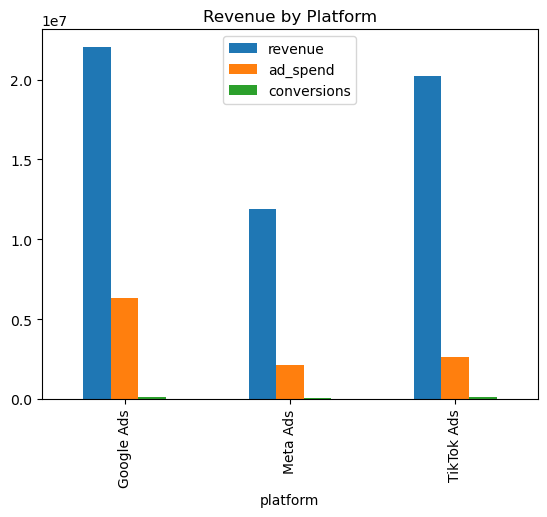

In [11]:
Platform_Performance = df.groupby('platform')[['revenue' , 'ad_spend' , 'conversions']].sum().plot(kind='bar')
plt.title('Revenue by Platform')
plt.show()

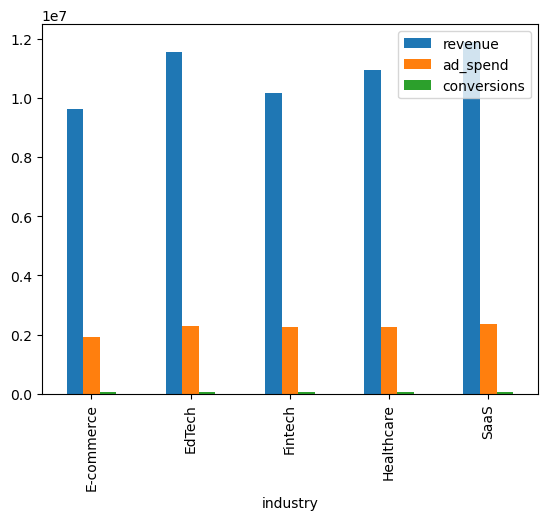

In [12]:
Platform_Performance = df.groupby('industry')[['revenue' , 'ad_spend' , 'conversions']].sum().plot(kind='bar')


In [13]:
Country_performance = df.groupby('country')['revenue'].sum()
Country_performance

country
Australia    7921847.84
Canada       7867323.12
Germany      7694838.61
India        7909606.26
UAE          7939594.41
UK           7659544.29
USA          7190576.28
Name: revenue, dtype: float64

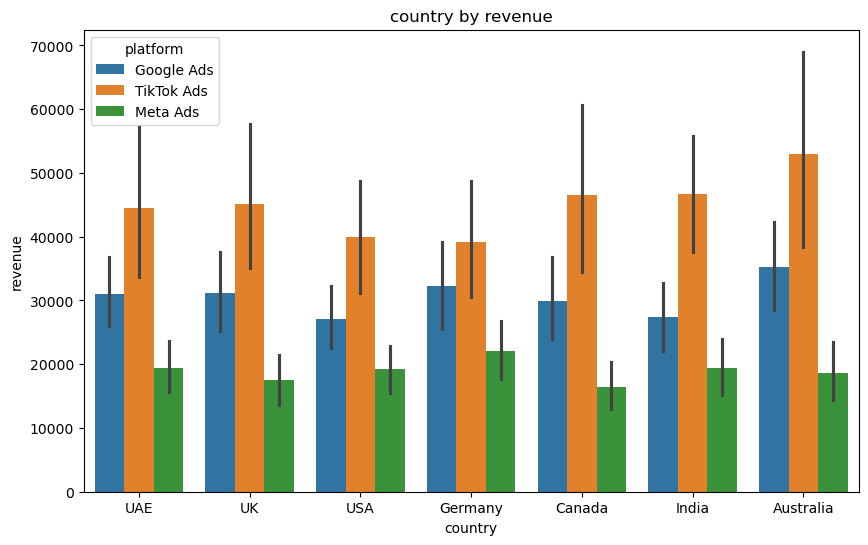

In [15]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df , x='country' , y='revenue', hue='platform')
plt.title('country by revenue')
plt.show()

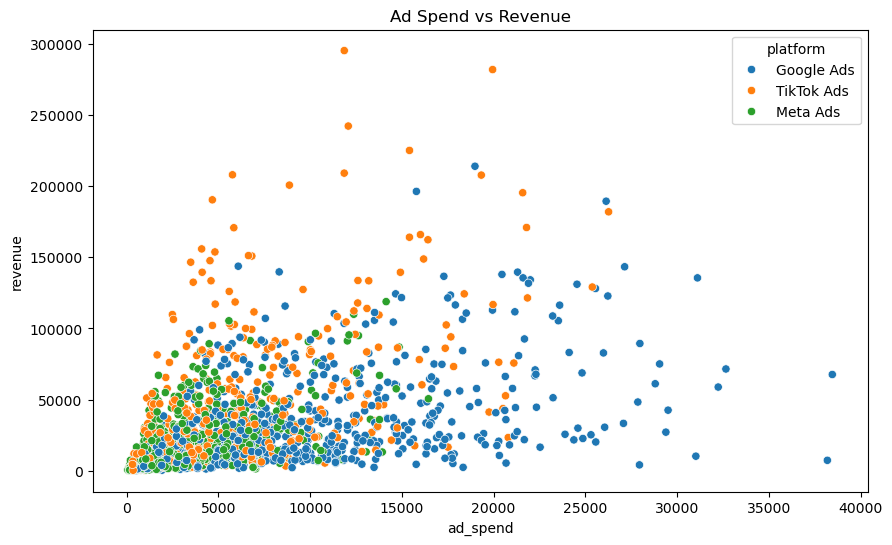

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot( data=df , x="ad_spend" , y="revenue" ,hue='platform')
plt.title('Ad Spend vs Revenue')
plt.show()

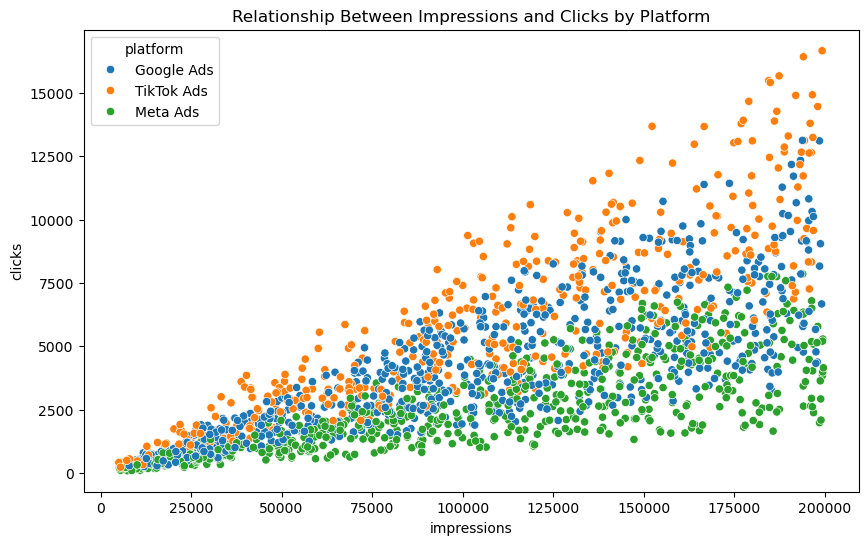

In [41]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot( data=df , x="impressions" , y="clicks" ,hue='platform')
plt.title('Relationship Between Impressions and Clicks by Platform')
plt.show()

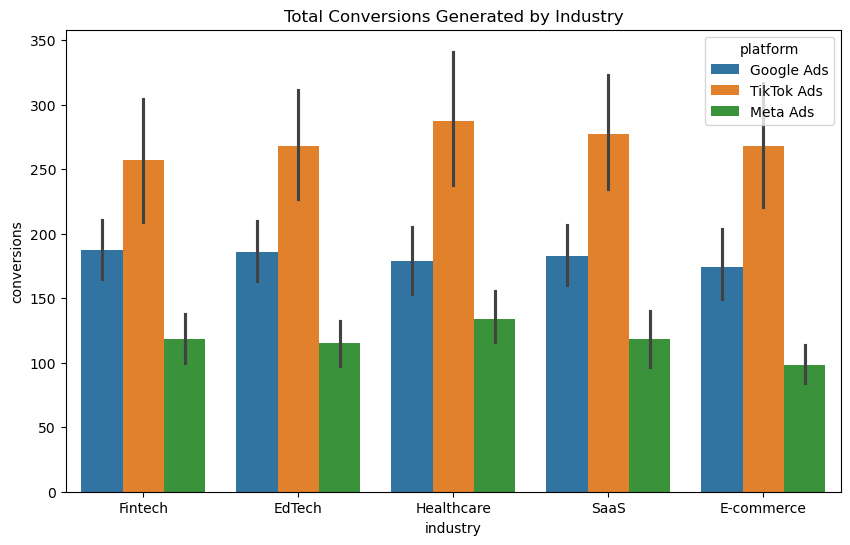

In [45]:
fig = plt.figure(figsize=(10,6))
sns.barplot( data=df , x="industry" , y="conversions" , hue= 'platform')
plt.title('Total Conversions Generated by Industry')
plt.show()


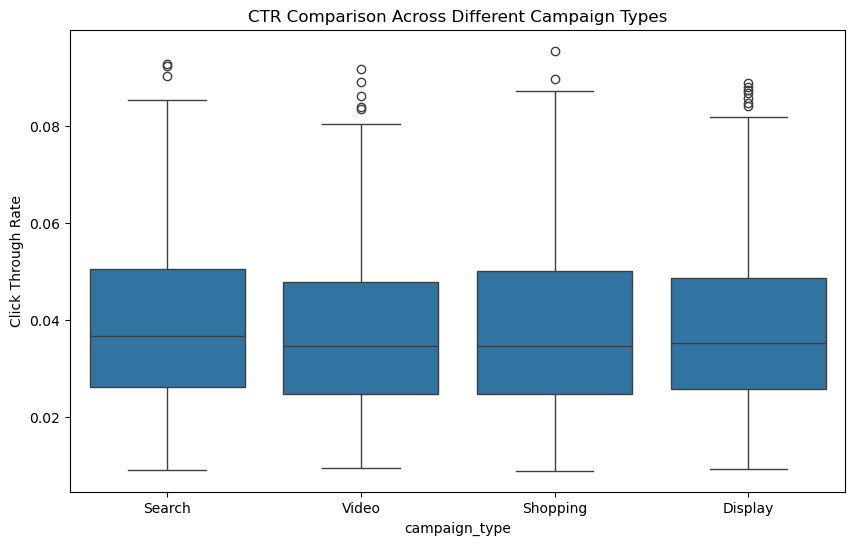

In [46]:
fig = plt.figure(figsize=(10,6))
sns.boxplot( data=df , x="campaign_type" , y="Click Through Rate" )
plt.title('CTR Comparison Across Different Campaign Types')
plt.show()


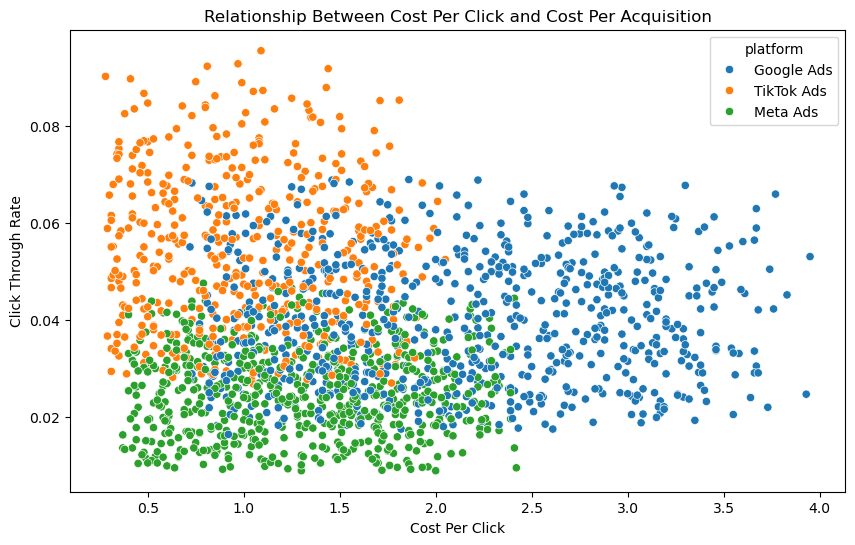

In [20]:
fig = plt.figure(figsize = (10,6))
sns.scatterplot(data = df , x="Cost Per Click" , y="Click Through Rate" , hue="platform")
plt.title("Relationship Between Cost Per Click and Cost Per Acquisition")
plt.show()

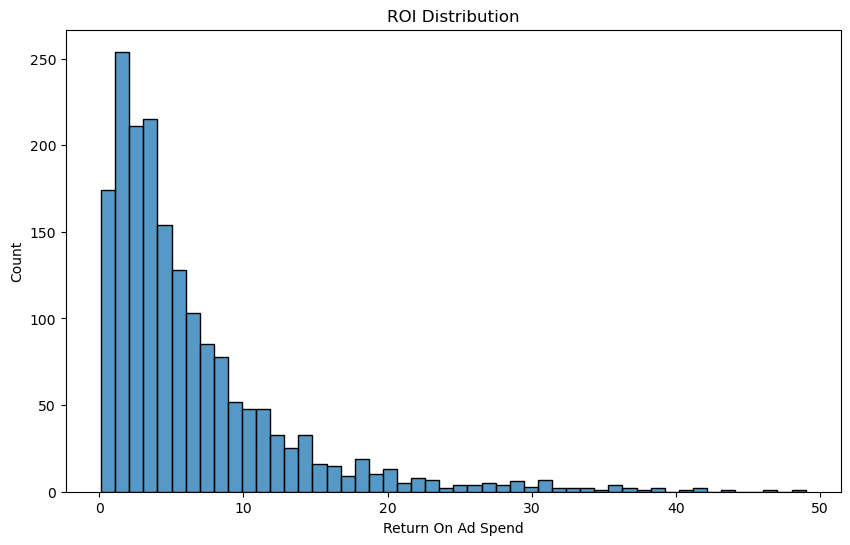

In [24]:
fig = plt.figure(figsize = (10,6))
sns.histplot(data = df , x="Return On Ad Spend")
plt.title("ROI Distribution")
plt.show()

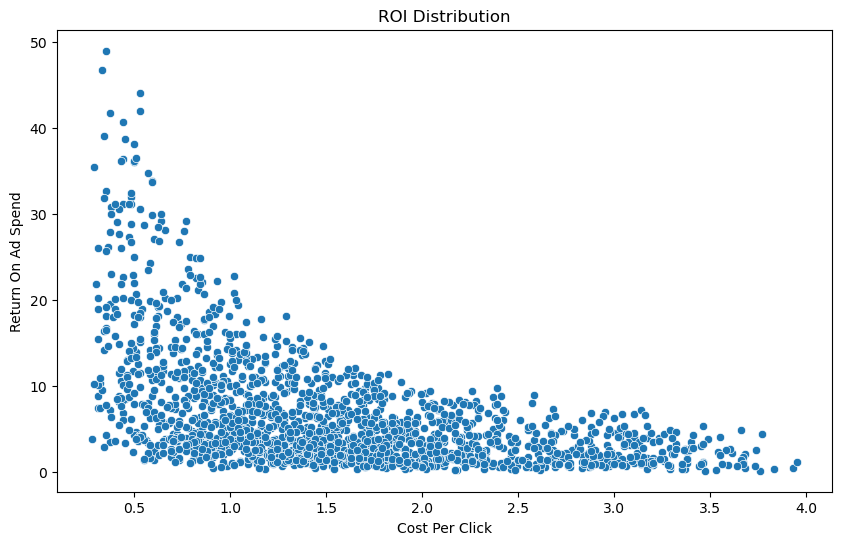

In [28]:
fig = plt.figure(figsize = (10,6))
sns.scatterplot(data = df , x="Cost Per Click", y="Return On Ad Spend")
plt.title("ROI Distribution")
plt.show()

In [31]:
df['Profit'] = df['revenue'] - df['ad_spend'] 

df['ROI'] = (df['Profit'] / df['ad_spend'])*100

In [47]:
df.head()

,date,platform,campaign_type,industry,country,impressions,clicks,Click Through Rate,Cost Per Click,ad_spend,conversions,Cost Per Acquisition,revenue,Return On Ad Spend,date_year,Profit,ROI,months
0,2024-01-21,Google Ads,Search,Fintech,UAE,59886,2113,0.0353,1.26,2662.38,159,16.74,4803.43,1.80,1,2141.05,80.418648,Jan
1,2024-01-22,TikTok Ads,Search,EdTech,UK,135608,5220,0.0385,1.18,6159.60,411,14.99,64126.68,10.41,1,57967.08,941.085135,Jan
2,2024-06-15,TikTok Ads,Video,Healthcare,USA,92313,5991,0.0649,0.85,5092.35,267,19.07,10489.07,2.06,6,5396.72,105.977005,Jun
3,2024-01-02,TikTok Ads,Shopping,SaaS,Germany,83953,5935,0.0707,1.32,7834.20,296,26.47,50505.07,6.45,1,42670.87,544.674249,Jan
4,2024-02-22,TikTok Ads,Search,Healthcare,UK,91807,4489,0.0489,1.93,8663.77,107,80.97,3369.53,0.39,2,-5294.24,-61.107809,Feb


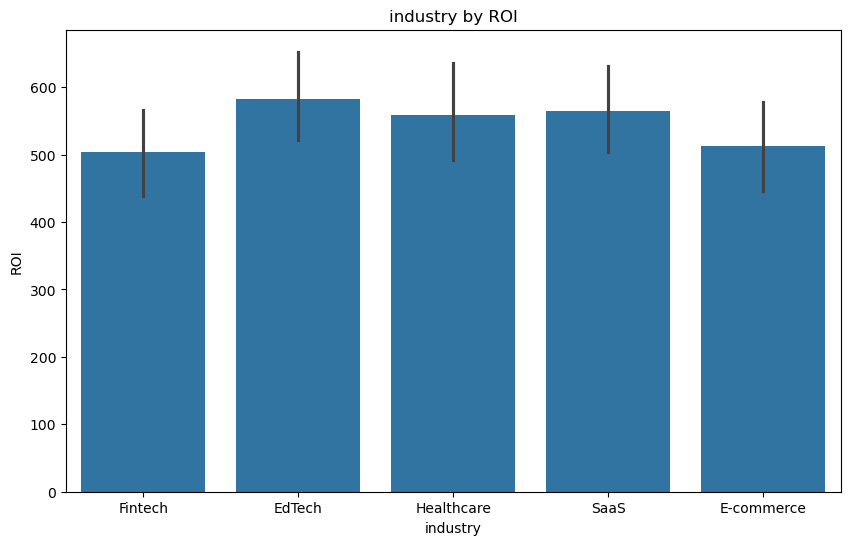

In [33]:
fig = plt.figure(figsize = (10,6))
sns.barplot(data = df , x="industry", y="ROI")
plt.title("industry by ROI")
plt.show()

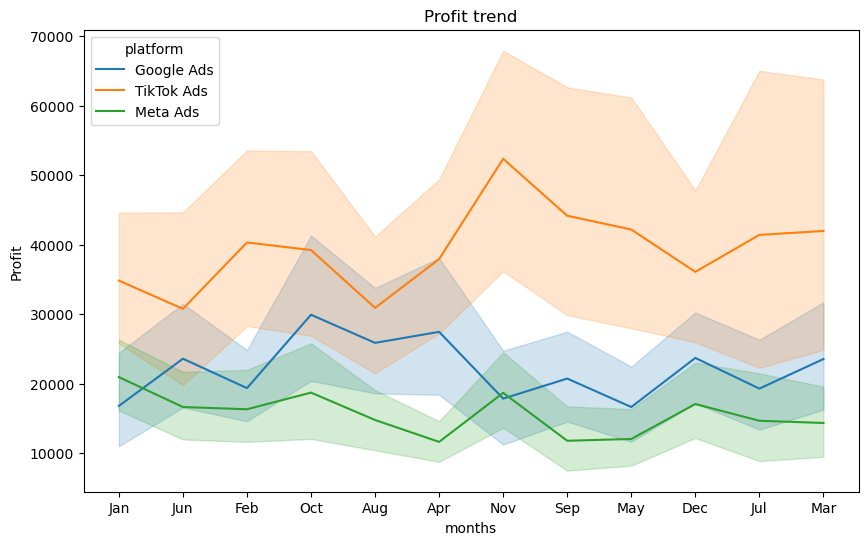

In [46]:
fig = plt.figure(figsize = (10,6))
sns.lineplot(data = df , x="months", y="Profit" , hue="platform")
plt.title("Profit trend")
plt.show()

In [51]:
from sqlalchemy import create_engine
# Step 1: Connect to PostgreSQL
# Replace placeholders with your actual details
username = "postgres"
password = "abhi112233"
host = "localhost"         # if running locally
port = "5432"              # default PostgreSQL port
database = "marketing_compaign"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")
table_name = "compaign"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")


Data successfully loaded into table 'compaign' in database 'marketing_compaign'.
